In [2]:
# ============================================================
# HMDB-ONLY BENCHMARKS (NO ALPHA SWEEP) — MAE-MSI ONLY
# GROUPED-SPLIT BY dataset_id (NO LEAKAGE)
#
# You asked:
# ✅ Only MAE-MSI
# ✅ Variants to benchmark:
#    - chan_only              (MSI_CHAN baseline; built from raw channel embeddings)
#    - chan+smiles            (load fused_chan__MAE-MSI.npy)
#    - cls+smiles             (load fused_tile__MAE-MSI.npy)
#    - cls+chan+smiles        (load fused_all__MAE-MSI.npy)
#    - chan+mzpol             (build on the fly; replaces smiles)
#    - cls+mzpol              (build on the fly; replaces smiles)
#    - cls+chan+mzpol         (build on the fly; replaces smiles)
#
# ✅ Only HMDB tasks:
#    - HMDB_super_class
#    - HMDB_class
#
# Notes:
# - Splits are CONSTANT per HMDB field and split_seed, built once at dataset-level
#   from channels_with_candidates.parquet (majority label per dataset).
# - MZPOL embedding uses your previous deterministic Fourier(mz)+polarity -> 768
#   and fuses with equal weights:
#      chan+mzpol:  l2( 0.5*l2(chan) + 0.5*l2(mzpol) )
#      cls+mzpol :  l2( 0.5*l2(cls)  + 0.5*l2(mzpol) )
#      all+mzpol :  l2( (1/3)*l2(cls) + (1/3)*l2(chan) + (1/3)*l2(mzpol) )
#
# Requirements:
#   pip install faiss-cpu
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*converge.*", category=ConvergenceWarning)
warnings.filterwarnings("ignore", module="sklearn")


# ============================================================
# PATHS
# ============================================================
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"
HMDB_PQ = BASE / "molformer_pubchem_index_enriched_semantic.parquet"  # contains hmdb_taxonomy + cid

ATLAS = Path("spatial_metabolomics_atlas")
FUSED_DIR = ATLAS / "channel_embeddings"

MSI_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_DIR / "meta.csv"
MSI_CLS_NPY  = MSI_DIR / "cls_embeddings.npy"

# MAE-MSI channel embeddings (tile_stack)
MSI_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel")
MSI_CHAN_ALL_NPY  = MSI_CHAN_DIR / "embeddings_all.npy"   # (Ntiles, C, D)
MSI_CHAN_ALL_META = MSI_CHAN_DIR / "meta__all.csv"        # has dataset_id,tile_r,tile_c,(split?)

OUT_ROOT = ATLAS / "benchmarks" / "hmdb"
OUT_LP   = OUT_ROOT / "linear_probe"
OUT_RET  = OUT_ROOT / "retrieval"
OUT_LP.mkdir(parents=True, exist_ok=True)
OUT_RET.mkdir(parents=True, exist_ok=True)

LP_RESULTS_CSV = OUT_LP / "results_all_variants.csv"
LP_SUMMARY_CSV = OUT_LP / "summary_meanstd_by_variant_field.csv"
LP_LEADER_CSV  = OUT_LP / "leaderboard_best_by_field.csv"
SPLITS_CSV     = OUT_ROOT / "constant_splits_report.csv"

RET_RESULTS_CSV = OUT_RET / "results_all_variants.csv"
RET_SUMMARY_CSV = OUT_RET / "summary_meanstd_by_variant_field_k.csv"
RET_LEADER_CSV  = OUT_RET / "leaderboard_best_by_field_k.csv"

HMDB_CACHE_DIR = OUT_ROOT / "_hmdb_cache"


# ============================================================
# CONFIG
# ============================================================
SEED = 6740

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.10
TEST_FRAC  = 0.20
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9

SPLIT_REPEATS = 3
SPLIT_SEEDS = [SEED + 1000 * r for r in range(SPLIT_REPEATS)]

# Linear probe
C_FIXED = 1.0
MAX_ITER_BIN   = 200
MAX_ITER_MULTI = 250
LP_TOL = 1e-4

# Retrieval
RETR_KS = [10]     # edit if you want [1,5,10,20]
RETR_METRIC = "cosine"  # faiss IP on l2 vectors

# HMDB fields
HMDB_FIELDS = ["super_class", "class"]
UNKNOWN_LABEL = "unknown"

# HMDB filters (row-level + train viability)
MIN_HMDB_CLASS_COUNT_GLOBAL_DSLEVEL = 2   # datasets per class to be eligible at dataset-level
MIN_HMDB_CLASS_COUNT_IN_TRAIN       = 50  # row-level codes count in TRAIN rows must pass

# channels parquet columns
DATASET_COL   = "dataset_id"
TILE_R_COL    = "tile_r"
TILE_C_COL    = "tile_c"
CHAN_IDX_COL  = "channel_idx"
MZ_COL        = "mz"
CAND_CIDS_COL = "cand_pubchem_cids"


# ============================================================
# Helpers: vector
# ============================================================
def l2_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32, order="C")
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def l2(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=np.float32)
    n = float(np.linalg.norm(v) + eps)
    return v / n

def l2norm(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return l2_rows(X, eps=eps)


# ============================================================
# HMDB taxonomy labeling (majority vote over candidate CIDs)
# ============================================================
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    seen, uniq = set(), []
    for cid in out:
        if cid not in seen:
            uniq.append(cid); seen.add(cid)
    return uniq

def _hmdb_tag(tax_str, key: str, default=UNKNOWN_LABEL) -> str:
    if tax_str is None:
        return default
    try:
        if pd.isna(tax_str):
            return default
    except Exception:
        pass

    key_l = key.lower()
    for p in str(tax_str).split(";"):
        p = p.strip()
        if not p:
            continue
        if p.lower().startswith(key_l + ":"):
            v = p.split(":", 1)[1].strip()
            return v if v else default
    return default

def build_cid_to_taxonomy(pq_path: Path) -> dict[str, str]:
    pq_df = pd.read_parquet(pq_path, columns=["cid", "hmdb_taxonomy"])
    pq_df["cid_norm"] = pq_df["cid"].astype(str).map(normalize_cid)
    cid_to_tax: dict[str, str] = {}
    for cid, tax in zip(pq_df["cid_norm"].values, pq_df["hmdb_taxonomy"].values):
        if cid and cid not in cid_to_tax:
            cid_to_tax[cid] = tax
    return cid_to_tax

def majority_vote(tags: list[str]) -> str:
    vc = pd.Series(tags).value_counts()
    return str(vc.index[0])

def label_row_by_hmdb_field_fast(cand_pubchem_cids, field: str, cid_to_tax: dict[str, str]) -> str:
    cids = parse_cids_field(cand_pubchem_cids)
    if not cids:
        return UNKNOWN_LABEL

    tags = []
    for cid in cids:
        tax = cid_to_tax.get(cid)
        if tax is None:
            continue
        v = _hmdb_tag(tax, field, default=UNKNOWN_LABEL)
        if v != UNKNOWN_LABEL:
            tags.append(v)

    if not tags:
        return UNKNOWN_LABEL
    return majority_vote(tags)

def compute_hmdb_labels_for_all_rows_cached(
    ch_df_all: pd.DataFrame,
    cid_to_tax: dict[str, str],
    cache_dir: Path,
    field: str,
) -> np.ndarray:
    """
    Caches a FULL row_id -> label mapping for this field across ALL rows.
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_csv = cache_dir / f"hmdb__{field}__ALLROWS.csv"

    if cache_csv.exists():
        df = pd.read_csv(cache_csv)
        m = dict(zip(df["row_id"].astype(np.int64).values, df["label"].astype(str).values))
        labels = np.array([m.get(int(i), UNKNOWN_LABEL) for i in range(len(ch_df_all))], dtype=object)
        print(f"[HMDB] loaded cached ALLROWS {field}: {cache_csv.name}")
        return labels.astype(object).astype(str)

    print(f"[HMDB] computing ALLROWS {field} for N={len(ch_df_all):,} ...")
    cids_col = ch_df_all[CAND_CIDS_COL].values
    labels = np.empty(len(ch_df_all), dtype=object)
    for i, cand_field in enumerate(tqdm(cids_col, desc=f"HMDB {field}", leave=False)):
        labels[i] = label_row_by_hmdb_field_fast(cand_field, field, cid_to_tax)

    pd.DataFrame({"row_id": np.arange(len(ch_df_all), dtype=np.int64), "label": labels.astype(str)}).to_csv(cache_csv, index=False)
    print(f"[HMDB] saved ALLROWS {field}: {cache_csv.name}")
    return labels.astype(object).astype(str)


# ============================================================
# Constant grouped splits at DATASET-level (per HMDB field, per seed)
# ============================================================
def stratified_group_split_dataset_ids(ds_ids, ds_labels, seed, train_frac, val_frac, test_frac):
    ds_ids = np.asarray(ds_ids).astype(str)
    ds_labels = np.asarray(ds_labels)

    if len(ds_ids) != len(ds_labels):
        raise ValueError("ds_ids and ds_labels must have same length")
    if len(np.unique(ds_labels)) < 2:
        raise ValueError("Need >=2 classes at dataset level for stratified split")

    idx_all = np.arange(len(ds_ids))

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed)
    idx_trva, idx_te = next(sss1.split(idx_all, ds_labels))

    labels_trva = ds_labels[idx_trva]
    val_frac2 = val_frac / max(train_frac + val_frac, 1e-12)

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_frac2, random_state=seed + 1)
    rel_tr, rel_va = next(sss2.split(np.arange(len(idx_trva)), labels_trva))

    idx_tr = idx_trva[rel_tr]
    idx_va = idx_trva[rel_va]

    return ds_ids[idx_tr], ds_ids[idx_va], ds_ids[idx_te]

def build_constant_dataset_splits_for_field(
    *,
    field: str,
    ch_dataset_vec: np.ndarray,
    hmdb_labels_allrows: np.ndarray,
    split_seeds: list[int],
) -> tuple[dict[int, dict[str, set[str]]], dict[str, str], pd.DataFrame]:
    """
    Returns:
      splits_by_seed: seed -> {"train": set(ds), "val": set(ds), "test": set(ds)}
      ds2label: dataset_id -> dataset-level HMDB label (mode over known row labels)
      report_df
    """
    ds = pd.Series(ch_dataset_vec.astype(str), name="dataset_id")
    y = pd.Series(hmdb_labels_allrows.astype(str), name="label")

    m_known = (y != UNKNOWN_LABEL) & (y != "") & (y != "nan")
    ds_k = ds[m_known].reset_index(drop=True)
    y_k  = y[m_known].reset_index(drop=True)

    dfk = pd.DataFrame({"dataset_id": ds_k.values, "label": y_k.values})

    # dataset-level label = mode of row-level labels within dataset
    ds_mode = (
        dfk.groupby("dataset_id")["label"]
           .agg(lambda s: str(pd.Series(s).value_counts().index[0]))
           .reset_index()
    )

    # drop dataset-level labels that have <2 datasets (strat split needs >=2 per class)
    vc_ds = ds_mode["label"].value_counts()
    ok_labels = vc_ds[vc_ds >= MIN_HMDB_CLASS_COUNT_GLOBAL_DSLEVEL].index.astype(str).tolist()
    ds_mode = ds_mode[ds_mode["label"].isin(ok_labels)].reset_index(drop=True)

    if ds_mode["label"].nunique() < 2:
        raise RuntimeError(f"[SPLIT] field={field}: <2 dataset-level classes after filtering. Lower MIN_HMDB_CLASS_COUNT_GLOBAL_DSLEVEL?")

    ds_ids = ds_mode["dataset_id"].astype(str).values
    y_ds  = pd.Categorical(ds_mode["label"].astype(str)).codes.astype(np.int64)

    ds2label = dict(zip(ds_mode["dataset_id"].astype(str), ds_mode["label"].astype(str)))

    splits_by_seed: dict[int, dict[str, set[str]]] = {}
    report_rows = []

    for split_seed in split_seeds:
        tr, va, te = stratified_group_split_dataset_ids(
            ds_ids=ds_ids,
            ds_labels=y_ds,
            seed=int(split_seed) + 100 + (hash(field) % 997),
            train_frac=TRAIN_FRAC,
            val_frac=VAL_FRAC,
            test_frac=TEST_FRAC,
        )
        splits_by_seed[int(split_seed)] = {
            "train": set(map(str, tr)),
            "val":   set(map(str, va)),
            "test":  set(map(str, te)),
        }

        report_rows.append({
            "field": field,
            "split_seed": int(split_seed),
            "n_ds_total": int(len(ds_ids)),
            "n_ds_train": int(len(tr)),
            "n_ds_val": int(len(va)),
            "n_ds_test": int(len(te)),
            "n_classes_dslevel": int(len(np.unique(y_ds))),
        })

    return splits_by_seed, ds2label, pd.DataFrame(report_rows)


# ============================================================
# Linear probe + Retrieval evaluators (HMDB only)
# ============================================================
def fit_logreg_fast(Xtr, ytr, Xte, yte, C, seed, max_iter, n_classes: int):
    # keep as your earlier "fast" style (no scaler)
    if n_classes <= 2:
        solver = "saga"
        n_jobs = 1
    else:
        solver = "lbfgs"
        n_jobs = 1

    clf = LogisticRegression(
        C=float(C),
        max_iter=int(max_iter),
        n_jobs=n_jobs,
        class_weight="balanced",
        random_state=int(seed),
        solver=solver,
        tol=float(LP_TOL),
    )
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    return {
        "acc": float(accuracy_score(yte, yhat)),
        "f1_macro": float(f1_score(yte, yhat, average="macro")),
    }

def faiss_knn_indices_ip(Xtr: np.ndarray, Xte: np.ndarray, K: int) -> np.ndarray:
    try:
        import faiss  # type: ignore
    except Exception as e:
        raise RuntimeError("FAISS not available. Install with: pip install faiss-cpu") from e

    Xtr = np.asarray(Xtr, dtype=np.float32, order="C")
    Xte = np.asarray(Xte, dtype=np.float32, order="C")

    d = int(Xtr.shape[1])
    index = faiss.IndexFlatIP(d)  # exact
    index.add(Xtr)
    K_eff = min(int(K), int(Xtr.shape[0]))
    _, I = index.search(Xte, K_eff)
    return I

def recall_at_k_vec(ytr: np.ndarray, yte: np.ndarray, idx_k: np.ndarray) -> float:
    nn_labels = ytr[idx_k]
    hits = (nn_labels == yte[:, None]).any(axis=1)
    return float(hits.mean()) if len(hits) else float("nan")

def purity_at_k_vec(ytr: np.ndarray, yte: np.ndarray, idx_k: np.ndarray) -> float:
    nn_labels = ytr[idx_k]
    frac = (nn_labels == yte[:, None]).mean(axis=1)
    return float(frac.mean()) if len(frac) else float("nan")

def map_at_k_vec(ytr: np.ndarray, yte: np.ndarray, idx_full: np.ndarray, K: int) -> float:
    K = min(int(K), int(idx_full.shape[1]))
    if K < 1:
        return float("nan")
    nn_labels = ytr[idx_full[:, :K]]
    rel = (nn_labels == yte[:, None]).astype(np.float32)
    n_rel = rel.sum(axis=1)
    cumsum = np.cumsum(rel, axis=1)
    ranks = np.arange(1, K + 1, dtype=np.float32)[None, :]
    prec = cumsum / ranks
    ap = (prec * rel).sum(axis=1) / np.maximum(n_rel, 1.0)
    ap[n_rel == 0] = 0.0
    return float(ap.mean()) if len(ap) else float("nan")


# ============================================================
# Channel-meta indexing (for chan_only and chan+mzpol/all+mzpol)
# ============================================================
SPLIT_PREFER_ORDER = ("train", "val", "test")

def build_chan_tile_index(meta_df: pd.DataFrame) -> tuple[dict[tuple, int], bool]:
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"channel meta missing columns: {sorted(miss)}")

    has_split = "split" in meta_df.columns
    key_to_i: dict[tuple, int] = {}
    for i, rr in meta_df.reset_index(drop=True).iterrows():
        ds = str(rr[DATASET_COL])
        tr = int(rr[TILE_R_COL])
        tc = int(rr[TILE_C_COL])
        if has_split:
            sp = str(rr["split"])
            key = (ds, tr, tc, sp)
        else:
            key = (ds, tr, tc)
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i, has_split

def infer_tile_key_for_chan_embeddings(
    row: pd.Series,
    *,
    chan_meta_has_split: bool,
    chan_tile_to_i: dict[tuple, int],
    prefer_order: tuple[str, ...] = SPLIT_PREFER_ORDER,
) -> tuple:
    ds = str(row.get(DATASET_COL))
    tr = int(row.get(TILE_R_COL))
    tc = int(row.get(TILE_C_COL))

    if not chan_meta_has_split:
        return (ds, tr, tc)

    if "split" in row.index and row.get("split") is not None:
        return (ds, tr, tc, str(row.get("split")))

    for sp in prefer_order:
        k = (ds, tr, tc, sp)
        if k in chan_tile_to_i:
            return k

    prefix = (ds, tr, tc)
    for k in chan_tile_to_i.keys():
        if len(k) == 4 and k[:3] == prefix:
            return k

    return (ds, tr, tc, prefer_order[0])

def fetch_chan_embeddings_for_row_ids(
    *,
    row_ids: np.ndarray,
    ch_df_full: pd.DataFrame,
    Z_all: np.ndarray,         # (Ntiles, C, D)
    meta_all: pd.DataFrame,    # tile index
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      X_out (N_kept, D) float32
      row_ids_kept (N_kept,)
    Drops any rows that cannot be mapped to a tile/channel.
    """
    tile_to_i, has_split = build_chan_tile_index(meta_all)

    D = int(Z_all.shape[2])
    X_out = np.empty((len(row_ids), D), dtype=np.float32)
    ok = np.ones(len(row_ids), dtype=bool)

    for j, rid in enumerate(tqdm(row_ids, desc="build chan embeddings", leave=False)):
        r = ch_df_full.iloc[int(rid)]
        k = int(r[CHAN_IDX_COL])

        key_tile = infer_tile_key_for_chan_embeddings(
            r, chan_meta_has_split=has_split, chan_tile_to_i=tile_to_i
        )
        ti = tile_to_i.get(key_tile)
        if ti is None or not (0 <= k < Z_all.shape[1]):
            ok[j] = False
            continue
        X_out[j, :] = np.asarray(Z_all[ti, k, :], dtype=np.float32)

    if not np.all(ok):
        row_ids_kept = row_ids[ok]
        X_out = X_out[ok]
        return X_out, row_ids_kept
    return X_out, row_ids


# ============================================================
# Polarity + MZPOL embedding (same definition as before)
# ============================================================
def infer_meta_polarity_column(meta: pd.DataFrame) -> str:
    cols = list(meta.columns)
    low = {c.lower(): c for c in cols}

    preferred = [
        "polarity",
        "ion_polarity",
        "ionisation_polarity",
        "ionization_polarity",
        "ionisation",
        "ionization",
    ]
    for k in preferred:
        if k in low:
            return low[k]

    for c in cols:
        if "pol" in c.lower():
            return c

    raise KeyError(
        "Could not find a polarity column in meta.csv. "
        "Rename/add a column containing 'pol' or set POL_COL manually."
    )

def pol_to_scalar(p) -> float:
    if p is None:
        return 0.0
    s = str(p).strip().lower()
    if not s or s in {"nan", "none"}:
        return 0.0
    if "neg" in s or s in {"-", "-1", "negative"}:
        return -1.0
    if "pos" in s or s in {"+", "+1", "1", "positive"}:
        return 1.0
    try:
        v = float(s)
        if v > 0:
            return 1.0
        if v < 0:
            return -1.0
        return 0.0
    except Exception:
        return 0.0

MZPOL_OUT_DIM       = 768
MZPOL_FOURIER_BANDS = 16
MZPOL_FOURIER_SCALE = 10.0
MZPOL_USE_LOG_MZ    = True

def fourier_mz_features(mz: np.ndarray, bands: int, scale: float, use_log: bool) -> np.ndarray:
    mz = np.asarray(mz, dtype=np.float32)
    mz2 = np.where(np.isfinite(mz) & (mz > 0), mz, np.nan).astype(np.float32)
    x = np.log(mz2) if use_log else mz2

    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)
        if not np.isfinite(med):
            med = 0.0
        x = np.where(np.isfinite(x), x, med).astype(np.float32)

    ks = (2.0 ** np.arange(int(bands), dtype=np.float32))[None, :]
    arg = (x[:, None] * ks) / float(scale)
    sin = np.sin(arg)
    cos = np.cos(arg)
    return np.concatenate([sin, cos], axis=1).astype(np.float32)

def build_mzpol_embedding_768(mz: np.ndarray, pol_scalar: np.ndarray) -> np.ndarray:
    mz_feat = fourier_mz_features(
        mz=mz,
        bands=int(MZPOL_FOURIER_BANDS),
        scale=float(MZPOL_FOURIER_SCALE),
        use_log=bool(MZPOL_USE_LOG_MZ),
    )
    pol_scalar = np.asarray(pol_scalar, dtype=np.float32).reshape(-1, 1)
    bias = np.ones((len(mz_feat), 1), dtype=np.float32)
    feats = np.concatenate([mz_feat, pol_scalar, bias], axis=1).astype(np.float32)

    rng = np.random.default_rng(SEED)
    W = rng.standard_normal((feats.shape[1], int(MZPOL_OUT_DIM)), dtype=np.float32)
    Z = feats @ W
    return l2_rows(Z)


def build_tile_key_to_cls_and_pol(msi_meta: pd.DataFrame, Z_cls_all: np.ndarray) -> tuple[dict[tuple, int], dict[tuple, float]]:
    POL_COL = infer_meta_polarity_column(msi_meta)
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL, POL_COL}
    miss = need - set(msi_meta.columns)
    if miss:
        raise KeyError(f"MSI meta.csv missing required columns: {sorted(miss)}")

    key_to_i: dict[tuple, int] = {}
    key_to_pol: dict[tuple, float] = {}
    for i, r in msi_meta.reset_index(drop=True).iterrows():
        key = (str(r[DATASET_COL]), int(r[TILE_R_COL]), int(r[TILE_C_COL]))
        if key not in key_to_i:
            key_to_i[key] = int(i)
            key_to_pol[key] = float(pol_to_scalar(r[POL_COL]))
    return key_to_i, key_to_pol


def compute_mzpol_for_row_ids(
    *,
    row_ids: np.ndarray,
    ch_df_full: pd.DataFrame,
    key_to_cls_i: dict[tuple, int],
    key_to_pol: dict[tuple, float],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For a given row_ids list:
      returns:
        mzpol_Z   (N_kept, 768)
        cls_idx   (N_kept,)   tile cls indices (for those rows)
        row_ids_kept (N_kept,)
    Drops rows where tile missing or mz not finite.
    """
    mz_vec = ch_df_full.iloc[row_ids][MZ_COL].to_numpy()
    ds_vec = ch_df_full.iloc[row_ids][DATASET_COL].astype(str).to_numpy()
    tr_vec = ch_df_full.iloc[row_ids][TILE_R_COL].astype(int).to_numpy()
    tc_vec = ch_df_full.iloc[row_ids][TILE_C_COL].astype(int).to_numpy()

    cls_idx = np.full(len(row_ids), -1, dtype=np.int64)
    pol_s   = np.zeros(len(row_ids), dtype=np.float32)

    for j in range(len(row_ids)):
        key = (str(ds_vec[j]), int(tr_vec[j]), int(tc_vec[j]))
        ti = key_to_cls_i.get(key, -1)
        cls_idx[j] = int(ti) if ti is not None else -1
        pol_s[j] = float(key_to_pol.get(key, 0.0))

    ok = (cls_idx >= 0) & np.isfinite(mz_vec)
    row_ids_kept = row_ids[ok]
    cls_idx_kept = cls_idx[ok]
    mz_kept = mz_vec[ok]
    pol_kept = pol_s[ok]

    if len(row_ids_kept) == 0:
        return np.empty((0, 768), dtype=np.float32), np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.int64)

    Z_mzpol = build_mzpol_embedding_768(mz=mz_kept, pol_scalar=pol_kept).astype(np.float32, copy=False)
    return Z_mzpol, cls_idx_kept, row_ids_kept


# ============================================================
# Variants: discovery + builders (MAE-MSI only)
# ============================================================
# ============================================================
# PATCH: add "msi_only" variant from:
#   fused_msi__MAE-MSI.npy + row_ids__msi__MAE-MSI.npy
# ============================================================
def load_fused(rep: str, kind: str) -> tuple[np.ndarray, np.ndarray]:
    """
    kind in {"tile","chan","all","msi"}
    """
    if kind == "tile":
        emb_p = FUSED_DIR / f"fused_tile__{rep}.npy"
        ids_p = FUSED_DIR / f"row_ids__tile__{rep}.npy"
    elif kind == "chan":
        emb_p = FUSED_DIR / f"fused_chan__{rep}.npy"
        ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
    elif kind == "all":
        emb_p = FUSED_DIR / f"fused_all__{rep}.npy"
        ids_p = FUSED_DIR / f"row_ids__all__{rep}.npy"
    elif kind == "msi":
        emb_p = FUSED_DIR / f"fused_msi__{rep}.npy"
        ids_p = FUSED_DIR / f"row_ids__msi__{rep}.npy"
    else:
        raise ValueError(kind)

    if not (emb_p.exists() and ids_p.exists()):
        raise FileNotFoundError(f"Missing fused files:\n  {emb_p}\n  {ids_p}")
    X = np.load(emb_p, mmap_mode="r")
    row_ids = np.asarray(np.load(ids_p), dtype=np.int64)
    if len(X) != len(row_ids):
        raise RuntimeError(f"Len mismatch: {emb_p.name} X={np.shape(X)} ids={row_ids.shape}")
    return X, row_ids


def build_variant_pack_mae_msi(
    *,
    ch_df_full: pd.DataFrame,
    Z_chan_all: np.ndarray,
    meta_chan_all: pd.DataFrame,
    Z_cls_all: np.ndarray,
    key_to_cls_i: dict[tuple, int],
    key_to_pol: dict[tuple, float],
) -> list[dict]:
    """
    Returns list of variant dicts:
      name, X(float32), row_ids(int64)
    """
    rep = "MAE-MSI"

    # SMILES fused variants (saved)
    X_tile, row_tile = load_fused(rep, "tile")
    X_chan, row_chan = load_fused(rep, "chan")
    X_all,  row_all  = load_fused(rep, "all")

    # NEW: MSI-only fused cls+chan (saved)
    X_msi, row_msi = load_fused(rep, "msi")

    variants: list[dict] = []

    # chan+smiles
    variants.append({"variant": "chan+smiles", "X": np.asarray(X_chan, dtype=np.float32, order="C"), "row_ids": row_chan})

    # cls+smiles
    variants.append({"variant": "cls+smiles", "X": np.asarray(X_tile, dtype=np.float32, order="C"), "row_ids": row_tile})

    # cls+chan+smiles
    variants.append({"variant": "cls+chan+smiles", "X": np.asarray(X_all, dtype=np.float32, order="C"), "row_ids": row_all})

    # NEW: msi_only (cls+chan, no smiles) — saved fusion
    variants.append({"variant": "cls+chan", "X": np.asarray(X_msi, dtype=np.float32, order="C"), "row_ids": row_msi})

    # chan_only baseline: use SAME row_ids as chan+smiles so row filtering matches
    X_chan_only, row_chan_only = fetch_chan_embeddings_for_row_ids(
        row_ids=row_chan,
        ch_df_full=ch_df_full,
        Z_all=Z_chan_all,
        meta_all=meta_chan_all,
    )
    variants.append({"variant": "chan_only", "X": X_chan_only, "row_ids": row_chan_only})

    # ============ MZPOL replacements (built on the fly) ============

    # (1) cls+mzpol: build on the cls+smiles row universe (row_tile)
    Z_mzpol_tile, cls_idx_tile, row_tile_mz = compute_mzpol_for_row_ids(
        row_ids=row_tile, ch_df_full=ch_df_full, key_to_cls_i=key_to_cls_i, key_to_pol=key_to_pol
    )
    if len(row_tile_mz) > 0:
        Z_cls_tile = l2_rows(Z_cls_all[cls_idx_tile].astype(np.float32, copy=False))
        X_cls_mzpol = l2_rows(0.5 * Z_cls_tile + 0.5 * Z_mzpol_tile).astype(np.float32, copy=False)
        variants.append({"variant": "cls+mzpol", "X": X_cls_mzpol, "row_ids": row_tile_mz})

    # (2) chan+mzpol: build on the chan_only/chan+smiles row universe (row_chan_only)
    Z_mzpol_chan, cls_idx_chan, row_chan_mz = compute_mzpol_for_row_ids(
        row_ids=row_chan_only, ch_df_full=ch_df_full, key_to_cls_i=key_to_cls_i, key_to_pol=key_to_pol
    )
    if len(row_chan_mz) > 0:
        X_chan_sub, row_chan_sub = fetch_chan_embeddings_for_row_ids(
            row_ids=row_chan_mz, ch_df_full=ch_df_full, Z_all=Z_chan_all, meta_all=meta_chan_all
        )
        if len(row_chan_sub) > 0:
            pos = {int(r): i for i, r in enumerate(row_chan_mz)}
            take = np.array([pos[int(r)] for r in row_chan_sub], dtype=np.int64)
            Z_mzpol_kept = Z_mzpol_chan[take]
            X_chan_kept  = l2_rows(X_chan_sub)
            X_chan_mzpol = l2_rows(0.5 * X_chan_kept + 0.5 * Z_mzpol_kept).astype(np.float32, copy=False)
            variants.append({"variant": "chan+mzpol", "X": X_chan_mzpol, "row_ids": row_chan_sub})

    # (3) cls+chan+mzpol: build on the cls+chan+smiles row universe (row_all)
    Z_mzpol_all, cls_idx_all, row_all_mz = compute_mzpol_for_row_ids(
        row_ids=row_all, ch_df_full=ch_df_full, key_to_cls_i=key_to_cls_i, key_to_pol=key_to_pol
    )
    if len(row_all_mz) > 0:
        X_chan_allsub, row_all_chan_kept = fetch_chan_embeddings_for_row_ids(
            row_ids=row_all_mz, ch_df_full=ch_df_full, Z_all=Z_chan_all, meta_all=meta_chan_all
        )
        if len(row_all_chan_kept) > 0:
            pos = {int(r): i for i, r in enumerate(row_all_mz)}
            take = np.array([pos[int(r)] for r in row_all_chan_kept], dtype=np.int64)

            Z_mzpol_kept = Z_mzpol_all[take]
            cls_idx_kept = cls_idx_all[take]

            Z_cls_kept   = l2_rows(Z_cls_all[cls_idx_kept].astype(np.float32, copy=False))
            Z_chan_kept  = l2_rows(X_chan_allsub)
            X_all_mzpol  = l2_rows((1.0/3.0) * Z_cls_kept + (1.0/3.0) * Z_chan_kept + (1.0/3.0) * Z_mzpol_kept).astype(np.float32, copy=False)

            variants.append({"variant": "cls+chan+mzpol", "X": X_all_mzpol, "row_ids": row_all_chan_kept})

    # sort deterministic
    order = [
        "chan_only",
        "chan+smiles",
        "cls+smiles",
        "cls+chan",              # NEW
        "cls+chan+smiles",
        "chan+mzpol",
        "cls+mzpol",
        "cls+chan+mzpol",
    ]
    variants = sorted(variants, key=lambda d: order.index(d["variant"]) if d["variant"] in order else 999)
    for v in variants:
        print(f"[VARIANT] {v['variant']:<16s} X={v['X'].shape} row_ids={v['row_ids'].shape}")
    return variants

# ============================================================
# Evaluation core (HMDB field only)
# ============================================================
def evaluate_variant_for_field(
    *,
    variant_name: str,
    X: np.ndarray,
    row_ids: np.ndarray,
    field: str,
    hmdb_labels_allrows_by_field: dict[str, np.ndarray],
    ch_dataset_vec: np.ndarray,
    splits_by_field: dict[str, dict[int, dict[str, set[str]]]],
    ds2label_by_field: dict[str, dict[str, str]],
) -> tuple[list[dict], list[dict]]:
    """
    Returns:
      lp_rows, ret_rows
    """
    y_allrows = hmdb_labels_allrows_by_field[field]
    ds2label = ds2label_by_field[field]
    splits_by_seed = splits_by_field[field]

    # restrict to rows in row_ids with known HMDB label and eligible dataset ids
    ds_rows = ch_dataset_vec[row_ids].astype(str)
    y_rows  = y_allrows[row_ids].astype(str)

    m_known = (y_rows != UNKNOWN_LABEL) & (y_rows != "") & (y_rows != "nan")
    row_ids_k = row_ids[m_known]
    ds_rows_k = ds_rows[m_known]
    y_rows_k  = y_rows[m_known]

    # restrict to datasets that are in ds2label (eligible at dataset-level)
    m_ds_ok = np.array([str(d) in ds2label for d in ds_rows_k], dtype=bool)
    row_ids_k = row_ids_k[m_ds_ok]
    ds_rows_k = ds_rows_k[m_ds_ok]
    y_rows_k  = y_rows_k[m_ds_ok]

    if len(row_ids_k) == 0:
        return [], []

    # build row-level codes with a stable category order (sorted by freq, then name)
    vc = pd.Series(y_rows_k).value_counts()
    cats = sorted(vc.index.astype(str).tolist(), key=lambda c: (-int(vc.get(c, 0)), str(c)))
    y_codes = pd.Categorical(pd.Series(y_rows_k).astype(str), categories=cats, ordered=True).codes.astype(np.int64)

    # slice embeddings to known rows (same order)
    # row_ids_k is subset of row_ids -> need positions
    pos = {int(r): i for i, r in enumerate(row_ids)}
    take = np.array([pos[int(r)] for r in row_ids_k], dtype=np.int64)
    Xk = np.asarray(X, dtype=np.float32, order="C")[take]

    lp_rows: list[dict] = []
    ret_rows: list[dict] = []

    Kmax = int(max(RETR_KS))

    for split_seed in SPLIT_SEEDS:
        sp = splits_by_seed[int(split_seed)]
        ds_tr = sp["train"]; ds_va = sp["val"]; ds_te = sp["test"]

        m_tr = np.array([d in ds_tr for d in ds_rows_k], dtype=bool)
        m_va = np.array([d in ds_va for d in ds_rows_k], dtype=bool)
        m_te = np.array([d in ds_te for d in ds_rows_k], dtype=bool)

        tr_idx = np.where(m_tr)[0]
        va_idx = np.where(m_va)[0]
        te_idx = np.where(m_te)[0]

        if len(tr_idx) < 10 or len(te_idx) < 10:
            continue

        ytr = y_codes[tr_idx]
        yte = y_codes[te_idx]

        # train viability filter: keep only classes with >= MIN_HMDB_CLASS_COUNT_IN_TRAIN in TRAIN rows
        vc_tr = pd.Series(ytr).value_counts()
        ok_classes = vc_tr[vc_tr >= MIN_HMDB_CLASS_COUNT_IN_TRAIN].index.astype(int).tolist()
        if len(ok_classes) < 2:
            continue

        m_okc = np.isin(y_codes, ok_classes)
        tr_idx2 = tr_idx[m_okc[tr_idx]]
        va_idx2 = va_idx[m_okc[va_idx]]
        te_idx2 = te_idx[m_okc[te_idx]]

        if len(tr_idx2) < 10 or len(te_idx2) < 10:
            continue

        # re-code to compact 0..C-1 for speed/stability
        # mapping only over ok_classes
        ok_classes_sorted = sorted(ok_classes)
        remap = {c: i for i, c in enumerate(ok_classes_sorted)}
        y2 = np.array([remap[int(c)] if int(c) in remap else -1 for c in y_codes], dtype=np.int64)
        ytr2 = y2[tr_idx2]
        yva2 = y2[va_idx2]
        yte2 = y2[te_idx2]

        if (ytr2 < 0).any() or (yte2 < 0).any():
            continue
        if len(np.unique(ytr2)) < 2 or len(np.unique(yte2)) < 2:
            continue

        Xtr = Xk[tr_idx2]
        Xva = Xk[va_idx2]
        Xte = Xk[te_idx2]

        n_classes = int(len(np.unique(y2[y2 >= 0])))
        max_iter = MAX_ITER_BIN if n_classes == 2 else MAX_ITER_MULTI

        # ---- Linear probe
        te = fit_logreg_fast(
            Xtr, ytr2, Xte, yte2,
            C=float(C_FIXED),
            seed=int(split_seed) + 77 + (hash(field + variant_name) % 997),
            max_iter=max_iter,
            n_classes=n_classes,
        )

        lp_rows.append({
            "variant": variant_name,
            "field": field,
            "split_seed": int(split_seed),
            "C_fixed": float(C_FIXED),
            "n_train": int(len(ytr2)),
            "n_val": int(len(yva2)),
            "n_test": int(len(yte2)),
            "n_classes": int(n_classes),
            "test_acc": float(te["acc"]),
            "test_f1_macro": float(te["f1_macro"]),
        })

        # ---- Retrieval
        Xtr_n = l2norm(Xtr)
        Xte_n = l2norm(Xte)

        idx_full = faiss_knn_indices_ip(Xtr_n, Xte_n, K=Kmax)
        for K in RETR_KS:
            K_eff = min(int(K), int(len(ytr2)))
            if K_eff < 1:
                continue
            idx_k = idx_full[:, :K_eff]

            rec  = recall_at_k_vec(ytr2, yte2, idx_k)
            pur  = purity_at_k_vec(ytr2, yte2, idx_k)
            mapk = map_at_k_vec(ytr2, yte2, idx_full, K=K_eff)

            ret_rows.append({
                "variant": variant_name,
                "field": field,
                "split_seed": int(split_seed),
                "K": int(K_eff),
                "metric": str(RETR_METRIC),
                "n_train": int(len(ytr2)),
                "n_test": int(len(yte2)),
                "n_classes": int(n_classes),
                "recall_at_k": float(rec),
                "map_at_k": float(mapk),
                "purity_at_k": float(pur),
            })

    return lp_rows, ret_rows


# ============================================================
# Summaries + leaderboards
# ============================================================
def summarize_lp(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    summ = (
        df.groupby(["field", "variant"], as_index=False)
          .agg(
              mean_f1=("test_f1_macro", "mean"),
              std_f1=("test_f1_macro", "std"),
              n=("test_f1_macro", "count"),
          )
          .sort_values(["field", "mean_f1"], ascending=[True, False])
          .reset_index(drop=True)
    )
    return summ

def summarize_ret(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    summ = (
        df.groupby(["field", "variant", "K"], as_index=False)
          .agg(
              recall_mean=("recall_at_k", "mean"),
              recall_std=("recall_at_k", "std"),
              map_mean=("map_at_k", "mean"),
              map_std=("map_at_k", "std"),
              purity_mean=("purity_at_k", "mean"),
              purity_std=("purity_at_k", "std"),
              n=("recall_at_k", "count"),
          )
          .sort_values(["field", "K", "recall_mean"], ascending=[True, True, False])
          .reset_index(drop=True)
    )
    return summ

def make_lp_leaderboard(summ: pd.DataFrame) -> pd.DataFrame:
    if summ.empty:
        return summ
    best = (
        summ.sort_values(["field", "mean_f1"], ascending=[True, False])
            .groupby("field", as_index=False)
            .head(1)
            .reset_index(drop=True)
    )
    best.insert(0, "section", "BEST_PER_FIELD")
    all2 = summ.copy()
    all2.insert(0, "section", "ALL")
    return pd.concat([best, all2], axis=0, ignore_index=True)

def make_ret_leaderboard(summ: pd.DataFrame, K_focus: int) -> pd.DataFrame:
    if summ.empty:
        return summ
    sub = summ[summ["K"].astype(int) == int(K_focus)].copy()
    if sub.empty:
        return sub

    rows = []
    for field in sorted(sub["field"].unique().tolist()):
        g = sub[sub["field"] == field].copy()

        # best by each metric (at K_focus)
        b1 = g.sort_values("recall_mean", ascending=False).head(1)
        if not b1.empty:
            rows.append({"field": field, "metric": f"Recall@K{K_focus}", **b1.iloc[0].to_dict()})

        b2 = g.sort_values("map_mean", ascending=False).head(1)
        if not b2.empty:
            rows.append({"field": field, "metric": f"mAP@K{K_focus}", **b2.iloc[0].to_dict()})

        b3 = g.sort_values("purity_mean", ascending=False).head(1)
        if not b3.empty:
            rows.append({"field": field, "metric": f"Purity@K{K_focus}", **b3.iloc[0].to_dict()})

    out = pd.DataFrame(rows)
    out.insert(0, "section", "BEST_PER_FIELD_PER_METRIC")
    return out


# ============================================================
# MAIN
# ============================================================
def main():
    # --- sanity
    for p in [CHAN_PQ, HMDB_PQ, MSI_META_CSV, MSI_CLS_NPY, MSI_CHAN_ALL_NPY, MSI_CHAN_ALL_META]:
        if not p.exists():
            raise FileNotFoundError(f"Missing: {p}")

    # --- load channels parquet (full; we need mz/tile/channel_idx)
    print("[LOAD] channels parquet (full):", CHAN_PQ)
    ch_df_full = pd.read_parquet(CHAN_PQ, columns=[DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL, MZ_COL, CAND_CIDS_COL]).reset_index(drop=True)
    ch_df_full[DATASET_COL] = ch_df_full[DATASET_COL].astype(str)
    ch_dataset_vec = ch_df_full[DATASET_COL].to_numpy()

    # --- HMDB labels ALLROWS (cached)
    print("[LOAD] building CID->taxonomy map ...")
    cid_to_tax = build_cid_to_taxonomy(HMDB_PQ)
    print(f"[INFO] CID->HMDB taxonomy entries: {len(cid_to_tax):,}")

    hmdb_labels_allrows_by_field: dict[str, np.ndarray] = {}
    for field in HMDB_FIELDS:
        hmdb_labels_allrows_by_field[field] = compute_hmdb_labels_for_all_rows_cached(
            ch_df_all=ch_df_full,
            cid_to_tax=cid_to_tax,
            cache_dir=HMDB_CACHE_DIR,
            field=field,
        )

    # --- constant dataset splits per field
    splits_by_field: dict[str, dict[int, dict[str, set[str]]]] = {}
    ds2label_by_field: dict[str, dict[str, str]] = {}
    split_reports = []

    for field in HMDB_FIELDS:
        splits_by_seed, ds2label, rep_df = build_constant_dataset_splits_for_field(
            field=field,
            ch_dataset_vec=ch_dataset_vec,
            hmdb_labels_allrows=hmdb_labels_allrows_by_field[field],
            split_seeds=SPLIT_SEEDS,
        )
        splits_by_field[field] = splits_by_seed
        ds2label_by_field[field] = ds2label
        split_reports.append(rep_df)

    split_report_df = pd.concat(split_reports, axis=0, ignore_index=True)
    split_report_df.to_csv(SPLITS_CSV, index=False)
    print("[OK] Saved:", SPLITS_CSV)

    # --- load CLS + meta (for mzpol)
    print("[LOAD] MAE-MSI CLS + meta")
    Z_cls_all = np.load(MSI_CLS_NPY, mmap_mode="r")
    if Z_cls_all.ndim != 2 or Z_cls_all.shape[1] != 768:
        raise RuntimeError(f"Expected CLS (N_tiles,768), got {Z_cls_all.shape}")
    msi_meta = pd.read_csv(MSI_META_CSV)
    key_to_cls_i, key_to_pol = build_tile_key_to_cls_and_pol(msi_meta, Z_cls_all)

    # --- load MAE-MSI channel embeddings_all (for chan_only / chan+mzpol / all+mzpol)
    print("[LOAD] MAE-MSI channel embeddings_all + meta__all")
    Z_chan_all = np.load(MSI_CHAN_ALL_NPY, mmap_mode="r")  # (Ntiles,C,D)
    meta_chan_all = pd.read_csv(MSI_CHAN_ALL_META)

    # --- build all variants (MAE-MSI only)
    variants = build_variant_pack_mae_msi(
        ch_df_full=ch_df_full,
        Z_chan_all=Z_chan_all,
        meta_chan_all=meta_chan_all,
        Z_cls_all=Z_cls_all,
        key_to_cls_i=key_to_cls_i,
        key_to_pol=key_to_pol,
    )
    if not variants:
        raise RuntimeError("No variants built.")

    # --- run eval
    all_lp_rows: list[dict] = []
    all_ret_rows: list[dict] = []

    for v in tqdm(variants, desc="variants", leave=True):
        for field in HMDB_FIELDS:
            lp_rows, ret_rows = evaluate_variant_for_field(
                variant_name=v["variant"],
                X=v["X"],
                row_ids=v["row_ids"],
                field=field,
                hmdb_labels_allrows_by_field=hmdb_labels_allrows_by_field,
                ch_dataset_vec=ch_dataset_vec,
                splits_by_field=splits_by_field,
                ds2label_by_field=ds2label_by_field,
            )
            all_lp_rows.extend(lp_rows)
            all_ret_rows.extend(ret_rows)

    # --- save raw
    df_lp = pd.DataFrame(all_lp_rows)
    df_ret = pd.DataFrame(all_ret_rows)

    df_lp.to_csv(LP_RESULTS_CSV, index=False)
    df_ret.to_csv(RET_RESULTS_CSV, index=False)
    print("[OK] Saved:", LP_RESULTS_CSV)
    print("[OK] Saved:", RET_RESULTS_CSV)

    # --- summarize + leaderboards
    lp_summ = summarize_lp(df_lp) if not df_lp.empty else pd.DataFrame()
    if not lp_summ.empty:
        lp_summ.to_csv(LP_SUMMARY_CSV, index=False)
        print("[OK] Saved:", LP_SUMMARY_CSV)

        lp_lead = make_lp_leaderboard(lp_summ)
        lp_lead.to_csv(LP_LEADER_CSV, index=False)
        print("[OK] Saved:", LP_LEADER_CSV)

    ret_summ = summarize_ret(df_ret) if not df_ret.empty else pd.DataFrame()
    if not ret_summ.empty:
        ret_summ.to_csv(RET_SUMMARY_CSV, index=False)
        print("[OK] Saved:", RET_SUMMARY_CSV)

        # leaderboard at the largest K
        K_focus = int(max(RETR_KS))
        ret_lead = make_ret_leaderboard(ret_summ, K_focus=K_focus)
        ret_lead.to_csv(RET_LEADER_CSV, index=False)
        print("[OK] Saved:", RET_LEADER_CSV)

    print("\n[DONE] Outputs:")
    print(" ", OUT_ROOT.resolve())


if __name__ == "__main__":
    main()

[LOAD] channels parquet (full): metaspace_images_dump\channels_with_candidates.parquet
[LOAD] building CID->taxonomy map ...
[INFO] CID->HMDB taxonomy entries: 30,478
[HMDB] loaded cached ALLROWS super_class: hmdb__super_class__ALLROWS.csv
[HMDB] loaded cached ALLROWS class: hmdb__class__ALLROWS.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\constant_splits_report.csv
[LOAD] MAE-MSI CLS + meta
[LOAD] MAE-MSI channel embeddings_all + meta__all


build chan embeddings:   0%|          | 0/157847 [00:00<?, ?it/s]

build chan embeddings:   0%|          | 0/157847 [00:00<?, ?it/s]

build chan embeddings:   0%|          | 0/157847 [00:00<?, ?it/s]

[VARIANT] chan_only        X=(157847, 768) row_ids=(157847,)
[VARIANT] chan+smiles      X=(157847, 768) row_ids=(157847,)
[VARIANT] cls+smiles       X=(157847, 768) row_ids=(157847,)
[VARIANT] cls+chan         X=(157847, 768) row_ids=(157847,)
[VARIANT] cls+chan+smiles  X=(157847, 768) row_ids=(157847,)
[VARIANT] chan+mzpol       X=(157847, 768) row_ids=(157847,)
[VARIANT] cls+mzpol        X=(157847, 768) row_ids=(157847,)
[VARIANT] cls+chan+mzpol   X=(157847, 768) row_ids=(157847,)


variants:   0%|          | 0/8 [00:00<?, ?it/s]

[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\linear_probe\results_all_variants.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\retrieval\results_all_variants.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\linear_probe\summary_meanstd_by_variant_field.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\linear_probe\leaderboard_best_by_field.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\retrieval\summary_meanstd_by_variant_field_k.csv
[OK] Saved: spatial_metabolomics_atlas\benchmarks\hmdb\retrieval\leaderboard_best_by_field_k.csv

[DONE] Outputs:
  \\bme-data2.ad.gatech.edu\labs6\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\hmdb


[OK] Saved summary: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\summary__hmdb_metrics__super_class__K10.csv


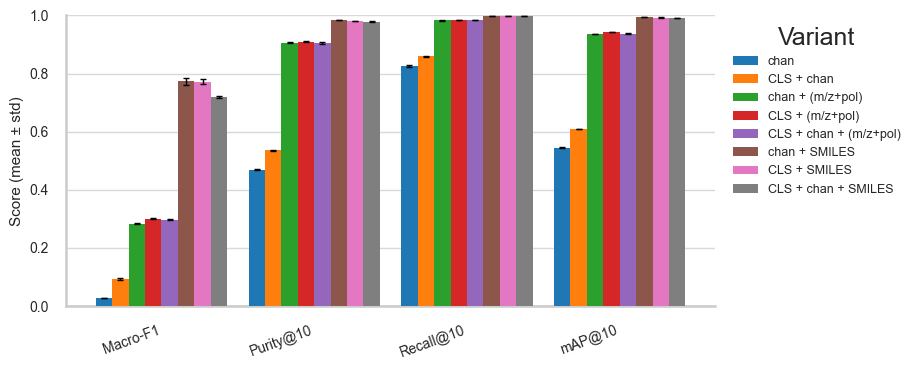

[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\barplot__hmdb_metrics__super_class__K10.png


In [4]:
# ============================================================
# HMDB-ONLY COMBINED PLOT (NO ALPHA SWEEP):
#   Linear probe (Macro-F1) + Retrieval metrics at K (Recall/mAP/Purity)
#   Compare: ALL fusion variants in one figure
#
# Reads:
#   spatial_metabolomics_atlas/benchmarks/hmdb/linear_probe/results_all_variants.csv
#   spatial_metabolomics_atlas/benchmarks/hmdb/retrieval/results_all_variants.csv
#
# Writes:
#   spatial_metabolomics_atlas/benchmarks/hmdb/combined_plots/
#     barplot__hmdb_metrics__<FIELD>__K<k>.png
#     summary__hmdb_metrics__<FIELD>__K<k>.csv
#
# Style updates:
#   ✅ same whitegrid-style look as the previous seaborn plots
#   ✅ horizontal grid lines
#   ✅ manual black std error bars
#   ✅ compact + figure-ready
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------- PATHS ----------------
ROOT = Path("spatial_metabolomics_atlas/benchmarks/hmdb")

LINEAR_RESULTS_CSV = ROOT / "linear_probe" / "results_all_variants.csv"
RETR_RESULTS_CSV   = ROOT / "retrieval"    / "results_all_variants.csv"

OUT_DIR = ROOT / "combined_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------- CONFIG ----------------
SEED = 6740

FIELD = "super_class"   # "super_class" or "class"
RETR_K = 10
RETR_METRICS_TO_PLOT = ["purity", "recall", "map"]  # any subset

# column expectations
LP_FIELD_COL   = "field"
LP_VAR_COL     = "variant"
LP_METRIC_COL  = "test_f1_macro"

RET_FIELD_COL  = "field"
RET_VAR_COL    = "variant"
RET_K_COL      = "K"
RET_RECALL_COL = "recall_at_k"
RET_MAP_COL    = "map_at_k"
RET_PURITY_COL = "purity_at_k"

# optional: enforce consistent variant order (any missing will be appended)
VARIANT_ORDER = [
    "chan_only",
    "cls+chan",
    "chan+mzpol",
    "cls+mzpol",
    "cls+chan+mzpol",
    "chan+smiles",
    "cls+smiles",
    "cls+chan+smiles",
]

# display names
VARIANT_DISPLAY = {
    "chan_only":        "chan",
    "cls+chan":         "CLS + chan",
    "chan+mzpol":       "chan + (m/z+pol)",
    "cls+mzpol":        "CLS + (m/z+pol)",
    "cls+chan+mzpol":   "CLS + chan + (m/z+pol)",
    "chan+smiles":      "chan + SMILES",
    "cls+smiles":       "CLS + SMILES",
    "cls+chan+smiles":  "CLS + chan + SMILES",
}

# fixed colors to match your earlier legend family
VARIANT_COLOR = {
    "chan_only":       "#1f77b4",  # blue
    "cls+chan":        "#ff7f0e",  # orange
    "chan+mzpol":      "#2ca02c",  # green
    "cls+mzpol":       "#d62728",  # red
    "cls+chan+mzpol":  "#9467bd",  # purple
    "chan+smiles":     "#8c564b",  # brown
    "cls+smiles":      "#e377c2",  # pink
    "cls+chan+smiles": "#7f7f7f",  # gray
}

# same overall style family as previous seaborn plots
sns.set(style="whitegrid", context="talk")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.axisbelow": True,  # grid behind bars
})


# ---------------- Helpers ----------------
def _pick_metric_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        key = str(cand).lower()
        if key in cols:
            return cols[key]
    return None


def _meanstd(vals: np.ndarray) -> tuple[float, float, int]:
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float("nan"), float("nan"), 0
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
    return mean, std, int(vals.size)


def _variant_sort_key(v: str) -> tuple[int, str]:
    if v in VARIANT_ORDER:
        return (VARIANT_ORDER.index(v), v)
    return (999, v)


def plot_grouped_bars_meanstd(
    df: pd.DataFrame,
    metric_order: list[str],
    variant_order: list[str],
    title: str,
    out_png: Path,
    ylabel: str = "Score (mean ± std)",
    ylim: tuple[float, float] | None = (0.0, 1.0),
    xtick_rotation: float = 20,
    extra_width_per_metric: float = 1.2,
):
    """
    df columns: metric, variant, mean, std
    x-axis = metric, grouped bars = variant
    """
    if df.empty:
        print("[WARN] empty df:", out_png)
        return

    df = df.copy()
    df["metric"] = df["metric"].astype(str)
    df["variant"] = df["variant"].astype(str)

    lookup = {}
    for _, r in df.iterrows():
        lookup[(r["metric"], r["variant"])] = (
            float(r["mean"]),
            float(r["std"]) if np.isfinite(r["std"]) else 0.0,
        )

    n_x = len(metric_order)
    n_h = len(variant_order)
    x0 = np.arange(n_x, dtype=float)

    total_width = 0.86
    bar_w = total_width / max(n_h, 1)

    fig_w = max(9.5, 5.5 + extra_width_per_metric * n_x)
    fig_h = 3.8
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for i_h, hv in enumerate(variant_order):
        xs = x0 - total_width / 2 + (i_h + 0.5) * bar_w

        means = np.full(n_x, np.nan, dtype=float)
        stds = np.full(n_x, np.nan, dtype=float)
        for i_x, xv in enumerate(metric_order):
            m, s = lookup.get((xv, hv), (np.nan, np.nan))
            means[i_x] = m
            stds[i_x] = s

        m_ok = np.isfinite(means)
        if not np.any(m_ok):
            continue

        ax.bar(
            xs[m_ok],
            means[m_ok],
            width=bar_w,
            label=VARIANT_DISPLAY.get(hv, hv),
            color=VARIANT_COLOR.get(hv, None),
            edgecolor="none",
            zorder=3,
        )

        ax.errorbar(
            xs[m_ok],
            means[m_ok],
            yerr=np.nan_to_num(stds[m_ok], nan=0.0),
            fmt="none",
            ecolor="black",
            capsize=2.5,
            linewidth=1.0,
            zorder=4,
        )

    # ---- match previous whitegrid-style appearance ----
    ax.set_facecolor("white")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=1.0)
    ax.grid(False, axis="x")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(x0)
    ax.set_xticklabels(metric_order, rotation=xtick_rotation, ha="right")

    if ylim is not None:
        ax.set_ylim(float(ylim[0]), float(ylim[1]))

    ax.legend(
        title="Variant",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        frameon=False,
        ncol=1,
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])

    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("[OK] Saved plot:", out_png)


# ---------------- Load + summarize ----------------
def summarize_all_metrics(field: str, K: int, metrics_to_plot: list[str]):
    if not LINEAR_RESULTS_CSV.exists():
        raise FileNotFoundError(f"Missing: {LINEAR_RESULTS_CSV}")
    if not RETR_RESULTS_CSV.exists():
        raise FileNotFoundError(f"Missing: {RETR_RESULTS_CSV}")

    lp = pd.read_csv(LINEAR_RESULTS_CSV)
    rt = pd.read_csv(RETR_RESULTS_CSV)

    # normalize
    lp[LP_FIELD_COL] = lp[LP_FIELD_COL].astype(str)
    lp[LP_VAR_COL] = lp[LP_VAR_COL].astype(str)
    lp[LP_METRIC_COL] = pd.to_numeric(lp[LP_METRIC_COL], errors="coerce")

    rt[RET_FIELD_COL] = rt[RET_FIELD_COL].astype(str)
    rt[RET_VAR_COL] = rt[RET_VAR_COL].astype(str)
    rt[RET_K_COL] = pd.to_numeric(rt[RET_K_COL], errors="coerce").astype("Int64")

    # filter by field
    lp_f = lp[lp[LP_FIELD_COL] == str(field)].copy()
    rt_f = rt[
        (rt[RET_FIELD_COL] == str(field)) &
        (rt[RET_K_COL].astype(int) == int(K))
    ].copy()

    if lp_f.empty:
        raise RuntimeError(f"No linear rows for field={field!r}")
    if rt_f.empty:
        raise RuntimeError(f"No retrieval rows for field={field!r} at K={K}")

    # which variants exist
    vars_lp = set(lp_f[LP_VAR_COL].unique().tolist())
    vars_rt = set(rt_f[RET_VAR_COL].unique().tolist())
    variants = sorted(list(vars_lp.union(vars_rt)), key=_variant_sort_key)

    rows = []

    # ---- Linear: Macro-F1
    for v in variants:
        vals = lp_f.loc[lp_f[LP_VAR_COL] == v, LP_METRIC_COL].dropna().astype(float).values
        m, s, n = _meanstd(vals)
        if n > 0:
            rows.append({
                "metric": "Macro-F1",
                "variant": v,
                "mean": m,
                "std": s,
                "n": n,
            })

    # ---- Retrieval metrics
    metric_map = {
        "purity": (RET_PURITY_COL, f"Purity@{int(K)}"),
        "recall": (RET_RECALL_COL, f"Recall@{int(K)}"),
        "map":    (RET_MAP_COL,    f"mAP@{int(K)}"),
    }

    col_purity = _pick_metric_col(rt_f, [RET_PURITY_COL, "purity", "purity@k", "purity_at_k"])
    col_recall = _pick_metric_col(rt_f, [RET_RECALL_COL, "recall", "recall@k", "recall_at_k"])
    col_map    = _pick_metric_col(rt_f, [RET_MAP_COL, "map", "map@k", "map_at_k", "mAP", "mAP@k"])

    col_lookup = {
        "purity": col_purity,
        "recall": col_recall,
        "map": col_map,
    }

    for mkey in metrics_to_plot:
        mkey = str(mkey).lower().strip()
        if mkey not in metric_map:
            raise ValueError(f"Unknown metric {mkey!r}. Use purity/recall/map.")

        col = col_lookup.get(mkey)
        if col is None:
            print(f"[WARN] Requested {mkey} but column not found in retrieval CSV; skipping.")
            continue

        _, pretty = metric_map[mkey]
        rt_col = pd.to_numeric(rt_f[col], errors="coerce")

        for v in variants:
            vals = rt_col[rt_f[RET_VAR_COL] == v].dropna().astype(float).values
            m, s, n = _meanstd(vals)
            if n > 0:
                rows.append({
                    "metric": pretty,
                    "variant": v,
                    "mean": m,
                    "std": s,
                    "n": n,
                })

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("Summary became empty (check requested metrics/field/K).")

    metric_order = ["Macro-F1"]
    for k in ["purity", "recall", "map"]:
        if k in [str(x).lower().strip() for x in metrics_to_plot]:
            metric_order.append(metric_map[k][1])

    out["metric"] = pd.Categorical(
        out["metric"].astype(str),
        categories=metric_order,
        ordered=True,
    )
    out = out.sort_values(["metric", "variant"], kind="mergesort").reset_index(drop=True)

    return out, metric_order, variants


# ---------------- Main ----------------
def main():
    metrics = [str(m).lower().strip() for m in RETR_METRICS_TO_PLOT]
    metrics = [m for m in metrics if m in {"purity", "recall", "map"}]
    if not metrics:
        raise ValueError("RETR_METRICS_TO_PLOT became empty; choose from: purity/recall/map.")

    summ, metric_order, variants = summarize_all_metrics(
        field=FIELD,
        K=RETR_K,
        metrics_to_plot=metrics,
    )

    out_csv = OUT_DIR / f"summary__hmdb_metrics__{FIELD}__K{int(RETR_K)}.csv"
    out_png = OUT_DIR / f"barplot__hmdb_metrics__{FIELD}__K{int(RETR_K)}.png"

    summ.to_csv(out_csv, index=False)
    print("[OK] Saved summary:", out_csv)

    plot_grouped_bars_meanstd(
        df=summ,
        metric_order=[str(m) for m in metric_order],
        variant_order=variants,
        title=f"",
        out_png=out_png,
        ylabel="Score (mean ± std)",
        ylim=(0.0, 1.0),
        xtick_rotation=20,
        extra_width_per_metric=1.2,
    )


if __name__ == "__main__":
    main()

[OK] Saved summary: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\summary__hmdb_linear_probe__K10.csv


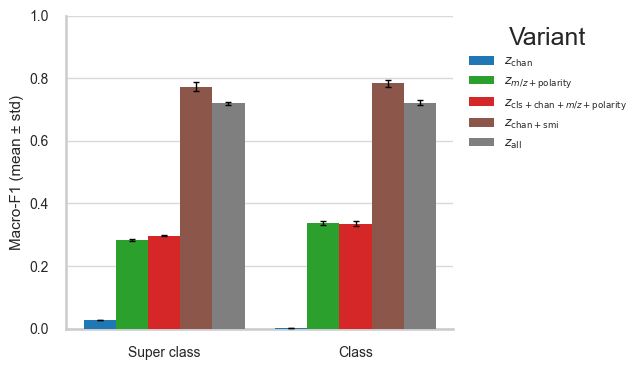

[OK] Saved linear-probe plot: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\barplot__hmdb_linear_probe__K10.png
[OK] Saved summary: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\summary__hmdb_retrieval__super_class_and_class__K10.csv


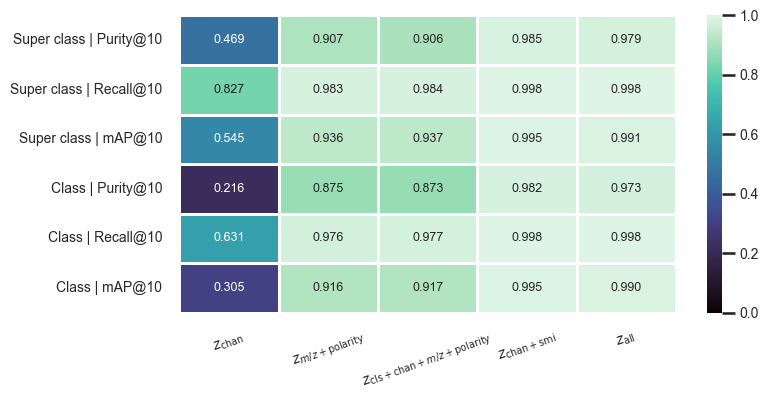

[OK] Saved retrieval heatmap: spatial_metabolomics_atlas\benchmarks\hmdb\combined_plots\heatmap__hmdb_retrieval__super_class_and_class__K10.png


In [14]:
# ============================================================
# HMDB PANELS (SEPARATED):
#   d) Linear probe only  -> grouped bars
#   e) Retrieval only     -> heatmap
#
# Compare ONLY the key variants:
#   1) chan_only
#   2) chan+mzpol
#   3) chan+smiles
#   4) cls+chan+smiles
#
# Reads:
#   spatial_metabolomics_atlas/benchmarks/hmdb/linear_probe/results_all_variants.csv
#   spatial_metabolomics_atlas/benchmarks/hmdb/retrieval/results_all_variants.csv
#
# Writes:
#   spatial_metabolomics_atlas/benchmarks/hmdb/combined_plots/
#     barplot__hmdb_linear_probe__K<k>.png
#     heatmap__hmdb_retrieval__K<k>.png
#     summary__hmdb_linear_probe__K<k>.csv
#     summary__hmdb_retrieval__K<k>.csv
#
# Style:
#   - Linear probe: whitegrid grouped bars with black std error bars
#   - Retrieval: compact heatmap with annotations
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------- PATHS ----------------
ROOT = Path("spatial_metabolomics_atlas/benchmarks/hmdb")

LINEAR_RESULTS_CSV = ROOT / "linear_probe" / "results_all_variants.csv"
RETR_RESULTS_CSV   = ROOT / "retrieval"    / "results_all_variants.csv"

OUT_DIR = ROOT / "combined_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------- CONFIG ----------------
SEED = 6740
RETR_K = 10

# Compare BOTH HMDB tasks in the linear-probe panel
LINEAR_FIELDS = ["super_class", "class"]

# Retrieval heatmap rows
RETR_METRICS_TO_PLOT = ["purity", "recall", "map"]   # subset of {"purity","recall","map"}

# Keep only the key variants for HMDB / chemical comparison
VARIANT_ORDER = [
    "chan_only",          # z_chan
    "chan+mzpol",         # engineered baseline
    "cls+chan+mzpol",    # engineered baseline + tile
    "chan+smiles",        # structure-aware fusion
    "cls+chan+smiles",    # z_all
]

VARIANT_DISPLAY = {
    "chan_only":        r"$z_{\mathrm{chan}}$",
    "chan+mzpol":       r"$z_{m/z+\mathrm{polarity}}$",
    "cls+chan+mzpol":   r"$z_{\mathrm{cls+chan}+m/z+\mathrm{polarity}}$",
    "chan+smiles":      r"$z_{\mathrm{chan+smi}}$",
    "cls+chan+smiles":  r"$z_{\mathrm{all}}$",
}

VARIANT_COLOR = {
    "chan_only":        "#1f77b4",
    "chan+mzpol":       "#2ca02c",
    "cls+chan+mzpol":   "#d62728",
    "chan+smiles":      "#8c564b",
    "cls+chan+smiles":  "#7f7f7f",
}

LINEAR_FIELD_DISPLAY = {
    "super_class": "Super class",
    "class": "Class",
}

RETR_METRIC_DISPLAY = {
    "purity": f"Purity@{RETR_K}",
    "recall": f"Recall@{RETR_K}",
    "map":    f"mAP@{RETR_K}",
}

# column expectations
LP_FIELD_COL   = "field"
LP_VAR_COL     = "variant"
LP_METRIC_COL  = "test_f1_macro"

RET_FIELD_COL  = "field"
RET_VAR_COL    = "variant"
RET_K_COL      = "K"
RET_RECALL_COL = "recall_at_k"
RET_MAP_COL    = "map_at_k"
RET_PURITY_COL = "purity_at_k"

sns.set(style="whitegrid", context="talk")
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.axisbelow": True,
})


# ---------------- Helpers ----------------
def _pick_metric_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        key = str(cand).lower()
        if key in cols:
            return cols[key]
    return None


def _meanstd(vals: np.ndarray) -> tuple[float, float, int]:
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float("nan"), float("nan"), 0
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
    return mean, std, int(vals.size)


def _ensure_exists(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")


def _filter_variants_present(df: pd.DataFrame, var_col: str, variant_order: list[str]) -> list[str]:
    present = set(df[var_col].astype(str).unique().tolist())
    return [v for v in variant_order if v in present]


# ---------------- Load ----------------
def load_results():
    _ensure_exists(LINEAR_RESULTS_CSV)
    _ensure_exists(RETR_RESULTS_CSV)

    lp = pd.read_csv(LINEAR_RESULTS_CSV)
    rt = pd.read_csv(RETR_RESULTS_CSV)

    # normalize dtypes
    lp[LP_FIELD_COL] = lp[LP_FIELD_COL].astype(str)
    lp[LP_VAR_COL] = lp[LP_VAR_COL].astype(str)
    lp[LP_METRIC_COL] = pd.to_numeric(lp[LP_METRIC_COL], errors="coerce")

    rt[RET_FIELD_COL] = rt[RET_FIELD_COL].astype(str)
    rt[RET_VAR_COL] = rt[RET_VAR_COL].astype(str)
    rt[RET_K_COL] = pd.to_numeric(rt[RET_K_COL], errors="coerce").astype("Int64")

    return lp, rt


# ---------------- Summaries ----------------
def summarize_linear_probe(lp: pd.DataFrame, fields: list[str], variant_order: list[str]) -> pd.DataFrame:
    rows = []

    lp_use = lp[lp[LP_FIELD_COL].isin(fields)].copy()
    if lp_use.empty:
        raise RuntimeError(f"No linear-probe rows found for fields={fields}")

    kept_variants = _filter_variants_present(lp_use, LP_VAR_COL, variant_order)
    if not kept_variants:
        raise RuntimeError("None of the requested variants were found in linear-probe results.")

    for field in fields:
        df_f = lp_use[lp_use[LP_FIELD_COL] == field].copy()
        for v in kept_variants:
            vals = df_f.loc[df_f[LP_VAR_COL] == v, LP_METRIC_COL].dropna().astype(float).values
            mean, std, n = _meanstd(vals)
            if n > 0:
                rows.append({
                    "field": field,
                    "field_pretty": LINEAR_FIELD_DISPLAY.get(field, field),
                    "variant": v,
                    "variant_pretty": VARIANT_DISPLAY.get(v, v),
                    "mean": mean,
                    "std": std,
                    "n": n,
                })

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("Linear-probe summary is empty after filtering.")
    return out


def summarize_retrieval(rt: pd.DataFrame, field: str, K: int, metrics_to_plot: list[str], variant_order: list[str]) -> pd.DataFrame:
    rt_use = rt[
        (rt[RET_FIELD_COL] == str(field)) &
        (rt[RET_K_COL].astype(int) == int(K))
    ].copy()

    if rt_use.empty:
        raise RuntimeError(f"No retrieval rows for field={field!r} at K={K}")

    kept_variants = _filter_variants_present(rt_use, RET_VAR_COL, variant_order)
    if not kept_variants:
        raise RuntimeError("None of the requested variants were found in retrieval results.")

    col_purity = _pick_metric_col(rt_use, [RET_PURITY_COL, "purity", "purity@k", "purity_at_k"])
    col_recall = _pick_metric_col(rt_use, [RET_RECALL_COL, "recall", "recall@k", "recall_at_k"])
    col_map    = _pick_metric_col(rt_use, [RET_MAP_COL, "map", "map@k", "map_at_k", "mAP", "mAP@k"])

    col_lookup = {
        "purity": col_purity,
        "recall": col_recall,
        "map": col_map,
    }

    rows = []
    for mkey in metrics_to_plot:
        mkey = str(mkey).lower().strip()
        col = col_lookup.get(mkey)
        if col is None:
            print(f"[WARN] Retrieval column for '{mkey}' not found; skipping.")
            continue

        pretty = RETR_METRIC_DISPLAY[mkey]
        vals_col = pd.to_numeric(rt_use[col], errors="coerce")

        for v in kept_variants:
            vals = vals_col[rt_use[RET_VAR_COL] == v].dropna().astype(float).values
            mean, std, n = _meanstd(vals)
            if n > 0:
                rows.append({
                    "field": field,
                    "metric": mkey,
                    "metric_pretty": pretty,
                    "variant": v,
                    "variant_pretty": VARIANT_DISPLAY.get(v, v),
                    "mean": mean,
                    "std": std,
                    "n": n,
                })

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("Retrieval summary is empty after filtering.")
    return out


# ---------------- Plots ----------------
def plot_linear_probe_grouped_bars(
    df: pd.DataFrame,
    variant_order: list[str],
    out_png: Path,
    ylabel: str = "Macro-F1 (mean ± std)",
    ylim: tuple[float, float] = (0.0, 1.0),
):
    """
    x-axis = HMDB task
    grouped bars = variants
    """
    if df.empty:
        print("[WARN] Empty linear-probe dataframe, skipping:", out_png)
        return

    field_order = [f for f in LINEAR_FIELDS if f in df["field"].astype(str).unique()]
    x_labels = [LINEAR_FIELD_DISPLAY.get(f, f) for f in field_order]

    lookup = {}
    for _, r in df.iterrows():
        lookup[(r["field"], r["variant"])] = (float(r["mean"]), float(r["std"]))

    n_x = len(field_order)
    n_h = len(variant_order)
    x0 = np.arange(n_x, dtype=float)

    total_width = 0.84
    bar_w = total_width / max(n_h, 1)

    fig, ax = plt.subplots(figsize=(7.6, 3.8))

    for i_h, v in enumerate(variant_order):
        xs = x0 - total_width / 2 + (i_h + 0.5) * bar_w
        means = []
        stds = []

        for field in field_order:
            m, s = lookup.get((field, v), (np.nan, np.nan))
            means.append(m)
            stds.append(s)

        means = np.asarray(means, dtype=float)
        stds = np.asarray(stds, dtype=float)
        ok = np.isfinite(means)

        if not np.any(ok):
            continue

        ax.bar(
            xs[ok],
            means[ok],
            width=bar_w,
            color=VARIANT_COLOR.get(v, None),
            edgecolor="none",
            label=VARIANT_DISPLAY.get(v, v),
            zorder=3,
        )
        ax.errorbar(
            xs[ok],
            means[ok],
            yerr=np.nan_to_num(stds[ok], nan=0.0),
            fmt="none",
            ecolor="black",
            capsize=2.5,
            linewidth=1.0,
            zorder=4,
        )

    ax.set_facecolor("white")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=1.0)
    ax.grid(False, axis="x")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title("")
    ax.set_xticks(x0)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_ylim(*ylim)

    ax.legend(
        title="Variant",
        bbox_to_anchor=(1.01, 1.0),
        loc="upper left",
        frameon=False,
        ncol=1,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 1])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("[OK] Saved linear-probe plot:", out_png)


def plot_retrieval_heatmap(
    df: pd.DataFrame,
    variant_order: list[str],
    metrics_to_plot: list[str],
    out_png: Path,
    vmin: float = 0.0,
    vmax: float = 1.0,
    cmap: str = "mako",
):
    """
    rows = (field, retrieval metric)
    cols = variants
    values = mean score
    """
    if df.empty:
        print("[WARN] Empty retrieval dataframe, skipping:", out_png)
        return

    field_order = ["super_class", "class"]
    metric_order = [m for m in metrics_to_plot if m in df["metric"].astype(str).unique()]

    row_keys = []
    row_labels = []
    for field in field_order:
        if field not in df["field"].astype(str).unique():
            continue
        for m in metric_order:
            sub = df[(df["field"] == field) & (df["metric"] == m)]
            if sub.empty:
                continue
            row_keys.append((field, m))
            row_labels.append(f"{LINEAR_FIELD_DISPLAY.get(field, field)} | {RETR_METRIC_DISPLAY[m]}")

    col_labels = [VARIANT_DISPLAY.get(v, v) for v in variant_order]

    mat = np.full((len(row_keys), len(variant_order)), np.nan, dtype=float)

    for i, (field, m) in enumerate(row_keys):
        for j, v in enumerate(variant_order):
            sub = df[
                (df["field"] == field) &
                (df["metric"] == m) &
                (df["variant"] == v)
            ]
            if not sub.empty:
                mat[i, j] = float(sub["mean"].iloc[0])

    heat_df = pd.DataFrame(mat, index=row_labels, columns=col_labels)

    fig_h = max(3.2, 0.52 * len(row_labels) + 1.0)
    fig, ax = plt.subplots(figsize=(8.2, fig_h))

    sns.heatmap(
        heat_df,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        linewidths=0.8,
        linecolor="white",
        square=False,
        annot_kws={"fontsize": 9},
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.tick_params(axis="x", rotation=20)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("[OK] Saved retrieval heatmap:", out_png)

# ---------------- Main ----------------
def main():
    lp, rt = load_results()

    # ---- Linear probe summary + plot
    summ_lp = summarize_linear_probe(
        lp=lp,
        fields=LINEAR_FIELDS,
        variant_order=VARIANT_ORDER,
    )
    out_csv_lp = OUT_DIR / f"summary__hmdb_linear_probe__K{RETR_K}.csv"
    out_png_lp = OUT_DIR / f"barplot__hmdb_linear_probe__K{RETR_K}.png"
    summ_lp.to_csv(out_csv_lp, index=False)
    print("[OK] Saved summary:", out_csv_lp)

    lp_variants_present = [v for v in VARIANT_ORDER if v in summ_lp["variant"].astype(str).unique()]
    plot_linear_probe_grouped_bars(
        df=summ_lp,
        variant_order=lp_variants_present,
        out_png=out_png_lp,
        ylabel="Macro-F1 (mean ± std)",
        ylim=(0.0, 1.0),
    )

    # ---- Retrieval summary + heatmap (BOTH super_class and class)
    retrieval_fields = ["super_class", "class"]

    metrics = [str(m).lower().strip() for m in RETR_METRICS_TO_PLOT]
    metrics = [m for m in metrics if m in {"purity", "recall", "map"}]
    if not metrics:
        raise ValueError("RETR_METRICS_TO_PLOT became empty; choose from purity/recall/map.")

    retrieval_parts = []
    for retrieval_field in retrieval_fields:
        tmp = summarize_retrieval(
            rt=rt,
            field=retrieval_field,
            K=RETR_K,
            metrics_to_plot=metrics,
            variant_order=VARIANT_ORDER,
        )
        retrieval_parts.append(tmp)

    summ_rt = pd.concat(retrieval_parts, axis=0, ignore_index=True)

    out_csv_rt = OUT_DIR / f"summary__hmdb_retrieval__super_class_and_class__K{RETR_K}.csv"
    out_png_rt = OUT_DIR / f"heatmap__hmdb_retrieval__super_class_and_class__K{RETR_K}.png"
    summ_rt.to_csv(out_csv_rt, index=False)
    print("[OK] Saved summary:", out_csv_rt)

    rt_variants_present = [v for v in VARIANT_ORDER if v in summ_rt["variant"].astype(str).unique()]
    plot_retrieval_heatmap(
        df=summ_rt,
        variant_order=rt_variants_present,
        metrics_to_plot=metrics,
        out_png=out_png_rt,
        vmin=0.0,
        vmax=1.0,
        cmap="mako",
    )

if __name__ == "__main__":
    main()